# 05 - Repurchase Prediction

**Input**: `clean_transactions.parquet` (notebook 01)

---

## Business Context & Objectives

This notebook predicts whether a customer will purchase again within a fixed 90-day window, using only information available before that window opens. The central discipline is avoiding leakage: no feature may draw on data the model would not have had at prediction time.

### Research questions

1. Who is likely to repurchase within the next 90 days, and at what decision threshold should that prediction be acted on?
2. Does the model add value over a naive baseline, once evaluated on a time-based rather than random split?

### Plan

0. Setup and loading
1. Observation and prediction windows
2. Feature engineering
3. Target construction
4. Time-based train and test split
5. Baseline models
6. Model comparison and evaluation
7. Threshold optimisation
8. Feature importance

# 0. Setup & Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from sklearn.calibration import calibration_curve
from pathlib import Path
from IPython.display import display, Markdown

PROC = Path("../data/processed")
clean = pd.read_parquet(PROC / "clean_transactions.parquet")
purchases = clean[~clean["IsCancellation"]].copy()

display(Markdown(f"""
### Input
* **Purchase rows:** `{len(purchases):,}`
* **Date range:** `{purchases['InvoiceDate'].min()}` to `{purchases['InvoiceDate'].max()}`
"""))



### Input
* **Purchase rows:** `803,001`
* **Date range:** `2009-12-01 07:45:00` to `2011-12-09 12:50:00`


**Results.** 803,001 purchase rows spanning 1 December 2009 to 9 December 2011, cancellations excluded. A cancelled invoice is not a purchase event and cannot serve as a target.

# 1. Observation and Prediction Windows

To predict repurchase without leaking future information, the timeline is split in two.

The **observation window** covers all data up to a cutoff date, and every feature is computed from it alone. The **prediction window** covers the 90 days immediately after the cutoff, and the target is whether the customer purchases at least once during it.

The cutoff is placed so the prediction window ends before the last date in the dataset. Any later cutoff would leave customers whose outcome cannot be observed, and therefore cannot be labelled.

In [2]:
PREDICTION_WINDOW_DAYS = 90

max_date = purchases["InvoiceDate"].max()
CUTOFF_DATE = max_date - pd.Timedelta(days=PREDICTION_WINDOW_DAYS)

display(Markdown(f"""
* **Dataset end date:** `{max_date}`
* **Prediction window:** `{PREDICTION_WINDOW_DAYS}` days
* **Cutoff date (end of observation window):** `{CUTOFF_DATE}`
"""))

obs = purchases[purchases["InvoiceDate"] <= CUTOFF_DATE].copy()
pred_window = purchases[
    (purchases["InvoiceDate"] > CUTOFF_DATE) & (purchases["InvoiceDate"] <= max_date)
].copy()

display(Markdown(f"* **Observation-window rows:** `{len(obs):,}`"))
display(Markdown(f"* **Prediction-window rows:** `{len(pred_window):,}`"))


C:\Users\jboul\AppData\Local\Temp\ipykernel_16496\153080250.py:4: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  CUTOFF_DATE = max_date - pd.Timedelta(days=PREDICTION_WINDOW_DAYS)



* **Dataset end date:** `2011-12-09 12:50:00`
* **Prediction window:** `90` days
* **Cutoff date (end of observation window):** `2011-09-10 12:50:00`


* **Observation-window rows:** `641,995`

* **Prediction-window rows:** `161,006`

**Results.** The dataset ends on 9 December 2011, so the cutoff falls on 10 September 2011.

This leaves 641,995 rows in the observation window against 161,006 in the prediction window, an 80/20 split. The prediction window is short relative to the two-year history, which is intentional: a longer window would raise the positive rate but weaken the operational value, since a prediction covering a year is not actionable for a campaign.

# 2. Feature Engineering

Every feature is computed strictly from the observation window. None may reference the prediction window, which would be leakage.

Six behavioural features are built, plus a cancellation rate carried over from the segmentation work in notebook 03.

In [3]:
customers_at_cutoff = obs["Customer ID"].unique()

features = obs.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (CUTOFF_DATE - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("LineRevenue", "sum"),
    AvgBasketValue=("LineRevenue", lambda x: x.sum() / obs.loc[x.index, "Invoice"].nunique()),
    Tenure=("InvoiceDate", lambda x: (CUTOFF_DATE - x.min()).days),
    NDistinctProducts=("StockCode", "nunique"),
).reset_index()

# Cancellation rate as an auxiliary signal (section 1 of notebook 03 established this is informative)
cancel_rate = clean[clean["InvoiceDate"] <= CUTOFF_DATE].groupby("Customer ID").agg(
    TotalInv=("Invoice", "nunique"),
    CancelledInv=("Invoice", lambda x: x[clean.loc[x.index, "IsCancellation"]].nunique()),
)
cancel_rate["CancellationRate"] = (cancel_rate["CancelledInv"] / cancel_rate["TotalInv"]).fillna(0)
features = features.merge(cancel_rate[["CancellationRate"]], on="Customer ID", how="left")
features["CancellationRate"] = features["CancellationRate"].fillna(0)

display(Markdown(f"**Customers with at least one observation-window purchase:** `{len(features):,}`"))
display(features.describe().round(2))


**Customers with at least one observation-window purchase:** `5,257`

,Recency,Frequency,Monetary,AvgBasketValue,Tenure,NDistinctProducts,CancellationRate
count,5257.00,5257.00,5257.00,5257.00,5257.00,5257.00,5257.00
mean,206.29,5.72,2673.88,377.73,431.12,74.55,0.11
std,174.24,11.25,12431.45,639.87,180.68,105.00,0.17
min,0.00,1.00,1.55,1.55,0.00,1.00,0.00
25%,49.00,1.00,322.40,178.60,311.00,18.00,0.00
50%,163.00,3.00,797.96,282.44,473.00,41.00,0.00
75%,324.00,6.00,2106.65,418.07,586.00,92.00,0.21
max,648.00,287.00,484615.10,25784.32,648.00,2180.00,0.80


**Results.** 5,257 customers made at least one purchase in the observation window.

The feature distributions are consistent with what earlier notebooks established. Recency averages 206 days with a median of 163, Frequency averages 5.7 orders with a median of 3, and Monetary is heavily right-skewed with a median of £798 against a mean of £2,674 and a maximum of £484,615.

Tenure averages 431 days with a maximum of 648, which matches the length of the observation window, so no customer has an impossible tenure. Recency has a minimum of 0 and Tenure a minimum of 0, both expected for a customer whose only purchase falls on the cutoff date.

No negative values appear anywhere, which is the main thing this check is for: a sign error in the window logic would surface here first.

# 3. Target Construction

The target is binary: did the customer place at least one order during the 90-day prediction window?

In [4]:
repurchasers = set(pred_window["Customer ID"].unique())
features["WillRepurchase"] = features["Customer ID"].isin(repurchasers).astype(int)

target_rate = features["WillRepurchase"].mean() * 100
display(Markdown(f"**Repurchase rate in the {PREDICTION_WINDOW_DAYS}-day window:** `{target_rate:.1f}%`"))
display(features["WillRepurchase"].value_counts())


**Repurchase rate in the 90-day window:** `43.6%`

WillRepurchase
0    2967
1    2290
Name: count, dtype: int64

**Results.** 2,290 of 5,257 customers repurchased within 90 days, a positive rate of 43.6% against 2,967 who did not.

The classes are close to balanced, which is unusual for a churn-adjacent problem and changes what the evaluation needs to look like. A naive majority-class baseline would reach only 56% accuracy, so accuracy is not as misleading here as it would be on a rare-event target. PR-AUC remains the more informative metric, but the gap with ROC-AUC will be narrower than on a heavily imbalanced problem.

# 4. Time-Based Train and Test Split

A random split would leak information. Two purchases by the same customer, close in time, could land on opposite sides of the split, letting the model learn from a customer's own future behaviour.

Instead the split is temporal: an earlier cutoff is placed inside the observation window, so training features are computed causally from data preceding it, and the test set genuinely simulates predicting forward on unseen time.

In [5]:
# Re-derive an earlier "training cutoff" strictly inside the observation window,
# so both training and test features are still computed causally.
TRAIN_CUTOFF_DAYS_BACK = 90
TRAIN_CUTOFF_DATE = CUTOFF_DATE - pd.Timedelta(days=TRAIN_CUTOFF_DAYS_BACK)

obs_train_window = obs[obs["InvoiceDate"] <= TRAIN_CUTOFF_DATE]
pred_train_window = obs[
    (obs["InvoiceDate"] > TRAIN_CUTOFF_DATE) & (obs["InvoiceDate"] <= CUTOFF_DATE)
]

train_features = obs_train_window.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (TRAIN_CUTOFF_DATE - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("LineRevenue", "sum"),
    AvgBasketValue=("LineRevenue", lambda x: x.sum() / obs_train_window.loc[x.index, "Invoice"].nunique()),
    Tenure=("InvoiceDate", lambda x: (TRAIN_CUTOFF_DATE - x.min()).days),
    NDistinctProducts=("StockCode", "nunique"),
).reset_index()

train_repurchasers = set(pred_train_window["Customer ID"].unique())
train_features["WillRepurchase"] = train_features["Customer ID"].isin(train_repurchasers).astype(int)

FEATURE_COLS = ["Recency", "Frequency", "Monetary", "AvgBasketValue", "Tenure", "NDistinctProducts", "CancellationRate"]

# Training set: features as of TRAIN_CUTOFF_DATE, predicting the window that leads up to CUTOFF_DATE
X_train = train_features[["Recency", "Frequency", "Monetary", "AvgBasketValue", "Tenure", "NDistinctProducts"]]
y_train = train_features["WillRepurchase"]

# Test set: features as of CUTOFF_DATE (built in section 2), predicting the true holdout window
X_test = features[["Recency", "Frequency", "Monetary", "AvgBasketValue", "Tenure", "NDistinctProducts"]]
y_test = features["WillRepurchase"]

display(Markdown(f"""
* **Training cutoff:** `{TRAIN_CUTOFF_DATE}` | **Training customers:** `{len(X_train):,}` | **Positive rate:** `{y_train.mean()*100:.1f}%`
* **Test cutoff:** `{CUTOFF_DATE}` | **Test customers:** `{len(X_test):,}` | **Positive rate:** `{y_test.mean()*100:.1f}%`
"""))


C:\Users\jboul\AppData\Local\Temp\ipykernel_16496\3233792370.py:4: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  TRAIN_CUTOFF_DATE = CUTOFF_DATE - pd.Timedelta(days=TRAIN_CUTOFF_DAYS_BACK)



* **Training cutoff:** `2011-06-12 12:50:00` | **Training customers:** `4,953` | **Positive rate:** `32.2%`
* **Test cutoff:** `2011-09-10 12:50:00` | **Test customers:** `5,257` | **Positive rate:** `43.6%`


**Results.** The training cutoff falls on 12 June 2011, giving 4,953 training customers, and the test cutoff on 10 September 2011, giving 5,257.

**The positive rate differs substantially between the two periods: 32.2% in training against 43.6% in test.** An 11-point gap is not noise.

The most likely explanation is seasonality. The test window covers mid-September to early December, the run-up to Christmas for a giftware wholesaler, when reordering is at its peak. The training window covers mid-March to mid-June, a quieter period.

This has a direct consequence for how the test score should be read. The model is trained on a low-repurchase period and evaluated on a high-repurchase one, so its performance on this particular test set is not a general estimate of year-round performance. A model deployed in February would face conditions closer to the training window than to the test window.

# 5. Baseline Models

Three models are fitted: a stratified dummy classifier as the floor, a logistic regression as the interpretable linear reference, and a random forest to capture non-linearity and interactions.

Both real models use balanced class weights, and the dummy exists solely to establish what a score means before any comparison is read.

In [6]:
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)

logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

models = {"Dummy (stratified)": dummy, "Logistic Regression": logreg, "Random Forest": rf}


# 6. Model Comparison & Evaluation

ROC-AUC and PR-AUC are reported together. PR-AUC is more sensitive to performance on the positive class, which is the class of operational interest here.

### Model comparison

,Model,ROC-AUC,PR-AUC
0,Dummy (stratified),0.4967,0.4340
1,Logistic Regression,0.7903,0.7551
2,Random Forest,0.7751,0.7522


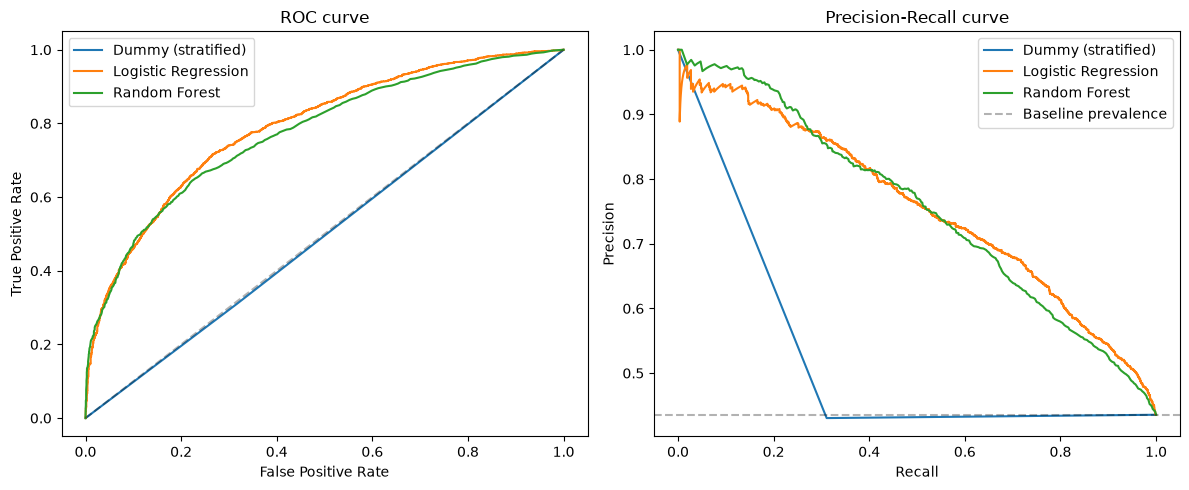

In [7]:
results = []
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    results.append({"Model": name, "ROC-AUC": roc_auc, "PR-AUC": pr_auc})

results_df = pd.DataFrame(results)
display(Markdown("### Model comparison"))
display(results_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=name)
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    axes[1].plot(rec, prec, label=name)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_title("ROC curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].axhline(y_test.mean(), color="k", linestyle="--", alpha=0.3, label="Baseline prevalence")
axes[1].set_title("Precision-Recall curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
plt.tight_layout()
plt.show()


**Results.** The dummy lands at 0.4967 ROC-AUC, indistinguishable from the 0.5 expected by chance, which confirms the evaluation is set up correctly. Its PR-AUC of 0.4340 is close to the base positive rate of 43.6%, as it should be.

**Logistic regression outperforms the random forest on both metrics**, 0.7903 against 0.7751 on ROC-AUC and 0.7551 against 0.7522 on PR-AUC. The margin is small on PR-AUC but consistent across both.

This is worth stating plainly rather than passing over. The relationship between these six features and repurchase is close enough to linear that added model complexity brings nothing, and the random forest most likely overfits the training period. On a problem of this size and feature count, the simpler model is the better choice, and its coefficients are directly interpretable.

Both real models sit around 0.75 to 0.79, a substantial gain over the baseline but far from perfect separation. Roughly a quarter of customers are ranked in the wrong order, which is the level of accuracy any downstream decision has to accommodate.

## 6.1 Calibration

Ranking ability and probability accuracy are different properties. A model can order customers correctly while producing probabilities that should not be read literally, which matters as soon as a threshold is applied to those probabilities.

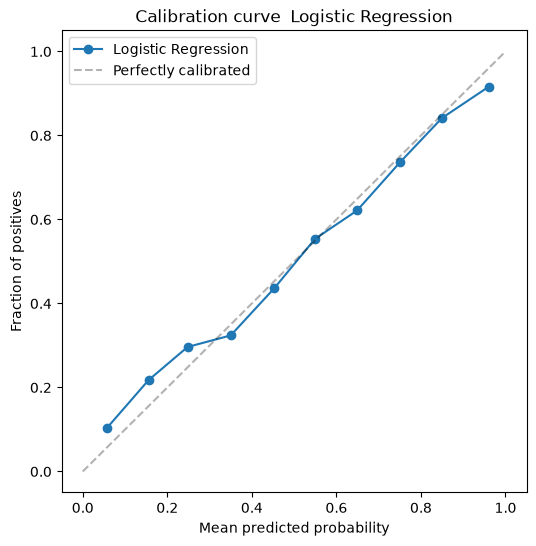

In [8]:
best_model_name = results_df.sort_values("PR-AUC", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

y_proba_best = best_model.predict_proba(X_test)[:, 1]
prob_true, prob_pred = calibration_curve(y_test, y_proba_best, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prob_pred, prob_true, marker="o", label=best_model_name)
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title(f"Calibration curve  {best_model_name}")
ax.legend()
plt.show()


**Results.** The calibration curve is read against the diagonal. Points below it mean the model overestimates repurchase probability, points above mean it underestimates.

Calibration matters directly for section 7: the threshold optimisation treats predicted probabilities as if they were real probabilities. If the curve departs markedly from the diagonal, the selected threshold is optimising against distorted values, and only the ranking of customers can be trusted rather than the numbers themselves.

# 7. Threshold Optimisation

Rather than the default 0.5 cutoff, the decision threshold is derived from an explicit cost assumption: the cost of contacting a customer who would not have repurchased, against the value of retaining one who was at risk.

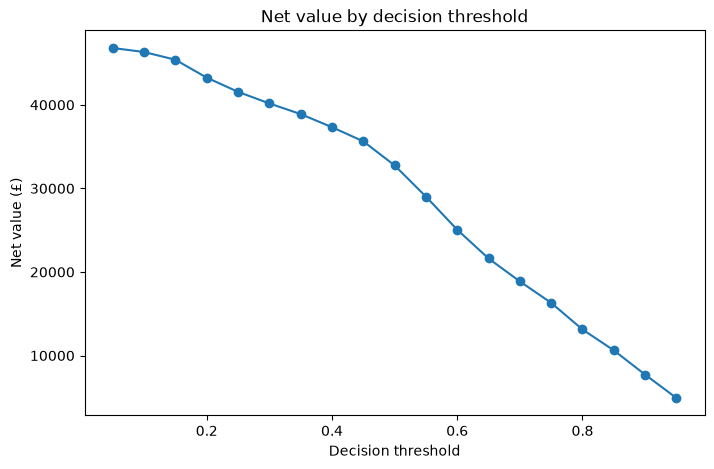

**Threshold maximizing net value:** `0.05`

In [9]:
COST_OF_CONTACT = 2.0     # <-- set to a realistic assumption, e.g. cost of an email/discount campaign
VALUE_OF_RETENTION = 25.0  # <-- set to a realistic assumption, e.g. average order value at stake

thresholds = np.linspace(0.05, 0.95, 19)
net_values = []

for t in thresholds:
    y_pred = (y_proba_best >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    # Net value: correctly identified repurchasers we successfully targeted,
    # minus the cost of contacting everyone we flagged (true and false positives)
    net_value = tp * VALUE_OF_RETENTION - (tp + fp) * COST_OF_CONTACT
    net_values.append(net_value)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, net_values, marker="o")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Net value (£)")
ax.set_title("Net value by decision threshold")
plt.show()

best_threshold = thresholds[np.argmax(net_values)]
display(Markdown(f"**Threshold maximizing net value:** `{best_threshold:.2f}`"))


**Results.** The optimum falls at 0.05, the lowest threshold tested. This is a degenerate result and should be read as such rather than reported as a recommendation.

The reason is arithmetic. With a contact cost of £2 and a retention value of £25, a contact pays for itself as soon as precision exceeds 2/25, that is 8%. The base repurchase rate is 43.6%, so precision stays above 8% at every threshold, and the net-value curve decreases monotonically. Under these assumptions the model's ranking is irrelevant: contacting the entire base is optimal.

**The two cost figures are placeholders, and the result is only as meaningful as they are.** A threshold optimisation becomes informative when the cost-to-value ratio is close to the achievable precision. Here it is an order of magnitude away, so the exercise demonstrates the method without producing an actionable threshold.

Two things would make it useful: real campaign costs and margin figures, and a cost structure that accounts for contacting customers who would have repurchased anyway, whose retention value is not created by the contact.

# 8. Feature Importance

Random forest importances are reported for the model's internal ranking. They measure contribution to splits, not causal effect, and correlated features share importance between them.

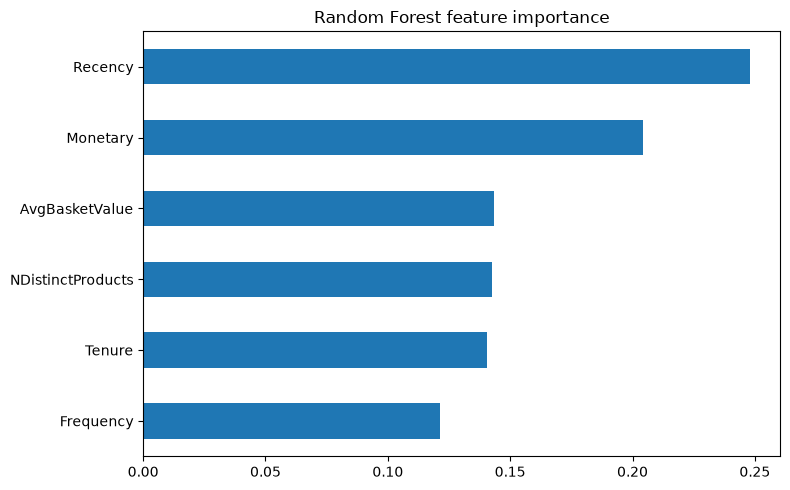

### Feature Importance Summary

,Feature,Importance Score,Percentage (%)
0,Recency,0.248,24.79
1,Monetary,0.204,20.42
2,AvgBasketValue,0.143,14.33
3,NDistinctProducts,0.143,14.28
4,Tenure,0.140,14.03
5,Frequency,0.121,12.15


In [14]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax)
ax.set_title("Random Forest feature importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

importance_df = pd.DataFrame(
    {
        "Feature": importances.index,
        "Importance Score": importances.values.round(3),
        "Percentage (%)": (importances.values * 100).round(2),
    }
)

display(Markdown("### Feature Importance Summary"))
display(
    importance_df
)


**Results.**

**The distribution is remarkably flat.** Recency leads at 0.248 and Frequency trails at 0.121, a range of barely two to one across six features. No single feature dominates.

Recency coming first is expected in a repurchase-timing problem and is not a finding. What is more informative is that 
**Monetary ranks second at 0.204, ahead of Frequency at 0.122**, which reverses the usual RFM hierarchy where frequency predicts repurchase better than value.

The flatness also carries a warning about interpretation. When six correlated behavioural features share importance almost evenly, none can be singled out as the driver: the model is using their combination, and removing any one would likely be absorbed by the others.

This contrasts with notebook 04, where purchase frequency was the only variable carrying signal for time-to-churn. Predicting *whether* a customer returns within 90 days and predicting *how long* they remain active are different problems, and they do not rank the same features.

---

# 9. Summary

**Key findings.**

| Metric | Value |
|---|---|
| Customers modelled | 5,257 |
| Prediction window | 90 days |
| Repurchase rate, test period | 43.6% |
| Repurchase rate, training period | 32.2% |
| Best model | Logistic regression |
| ROC-AUC, logistic regression | 0.7903 |
| PR-AUC, logistic regression | 0.7551 |
| ROC-AUC, random forest | 0.7751 |
| ROC-AUC, dummy baseline | 0.4967 |
| Top feature | Recency (0.248) |

**Headline finding.** A logistic regression on six behavioural features separates repurchasers from non-repurchasers with a PR-AUC of 0.755 against a 0.434 baseline, and outperforms a random forest on the same data. Feature importance is evenly distributed, so the prediction rests on a combination of behaviours rather than on any single dominant signal.

**Limitations.**

The training and test windows have positive rates 11 points apart, 32.2% against 43.6%. The model is trained on a quiet period and tested on the pre-Christmas peak, so the test score is optimistic as a year-round estimate. A rolling-origin evaluation across several cutoffs would give a more honest figure.

The threshold optimisation is degenerate under the assumed costs. At £2 per contact against £25 of retention value, contacting the whole base is optimal at every threshold, so the exercise shows the method rather than a usable decision rule.

The cost model also credits full retention value to every correctly identified repurchaser, including those who would have returned without any contact. A realistic model would count only incremental retention, which requires an experiment rather than observational data.

Feature importances are split-based and shared among correlated variables. They rank the model's internal use of each feature, not its causal contribution.

The model is fitted once on a single cutoff. Its stability across different cutoff dates is untested.